# Fire Resilience Combined Scorer
## Gary Ding &nbsp;&nbsp;&nbsp; February 26, 2026

Reads the suitability-scored plant list produced by the GoNative Suitability
Scorer notebook, integrates fire resilience evidence from ranked literature
sources, and produces a combined score via geometric weighted mean aggregation.

**Input:** `gonative_scores.xlsx` (upload when prompted)

**Output:** `gonative_combined_scored.xlsx`


---

## Step 1: Dependencies

In [ ]:
!pip install openpyxl -q
print("Ready.")

Ready.


## Step 2: Fire List Configuration

Lists are ranked by source authority (rank 1 = highest). Weights are
derived using a normalized linear ramp: w_j = (L+1−j) / Σi, where
L = number of lists and j = rank position. This automatically scales
to any number of lists.


In [20]:
# ════════════════════════════════════════════════════════════
# FIRE RESILIENCE LISTS — ordered by source authority (rank 1 = best)
# ════════════════════════════════════════════════════════════
# Plants can be listed by Hawaiian name, scientific name, or both.
# Matching is case-insensitive and diacritic-normalized.

FIRE_LISTS = [
    {   # Rank 1
        "name": "PFX Green Breaks",
        "citation": "PFX 30 Plants for Green Breaks (2023 expert survey, n=65)",
        "plants_hawaiian": [
            "Kou", "Naio", "Koaia", "Lonomea", "Pohuehue",
            "Naupaka kahakai", "Mao", "Ulei", "Alahe'e",
            "Uhaloa", "Aweoweo", "Pohinahina", "Akia", "Milo",
            "Hua", "Noni",
        ],
        "plants_scientific": [],
    },
    {   # Rank 2
        "name": "Loh et al. 2009",
        "citation": "Loh RK et al. (2009). Fire-adapted native species.",
        "plants_hawaiian": [
            "Koa", "He'upueo", "Pua kala", "Ko'oko'olau",
            "Awikiwiki", "A'ali'i", "Emoloa", "Naio", "Kolea",
            "Ulei", "Alahe'e", "Neneleau", "Pawale", "Iliahi",
            "Huahekili uka", "Kolomona", "Ohai", "Ilima",
            "Mamane", "Auhuhu", "Ohelo", "Uhaloa", "Akia",
        ],
        "plants_scientific": [],
    },
    {   # Rank 3
        "name": "Ka Pili Kai 2025",
        "citation": "Ka Pili Kai (2025). Drought/fire tolerant species.",
        "plants_hawaiian": [
            "Naupaka kahakai", "Wiliwili", "Koa", "Ohi'a lehua",
            "A'ali'i", "Naio", "Hinahina", "Alahe'e", "Milo",
        ],
        "plants_scientific": [],
    },
    {   # Rank 4
        "name": "Drought Tol. Index",
        "citation": "Drought Tolerance Index >70%.",
        "plants_hawaiian": [
            "A'ali'i", "Mamane", "Pilo", "Koa", "Ho'awa",
        ],
        "plants_scientific": [
            "Dodonaea viscosa", "Sophora chrysophylla",
            "Coprosma foliosa", "Acacia koa",
            "Pittosporum hosmeri",
        ],
    },
]

# Baseline for unlisted plants (0 = exclude from final ranking)
FIRE_BASELINE = 0.0

# ════════════════════════════════════════════════════════════
# COMBINED SCORE EXPONENTS
# ════════════════════════════════════════════════════════════
# C = S^a × F^b × 100  (geometric weighted mean)
# a + b should sum to 1. Higher a favors implementation
# feasibility (suitability); higher b favors fire evidence.
#   0.50 / 0.50 = equal influence (pure multiplication)
#   0.60 / 0.40 = suitability has 1.5× fire influence
#   0.65 / 0.35 = suitability has 1.9× fire influence
#   0.70 / 0.30 = suitability has 2.3× fire influence
EXPONENT_S = 0.5  # suitability exponent (a)
EXPONENT_F = 0.5  # fire resilience exponent (b)

OUTPUT_FILE = "gonative_combined_scored.xlsx"

print(f"Configured {len(FIRE_LISTS)} fire lists.")

Configured 4 fire lists.


## Step 3: Upload Suitability File & Run

Upload the file produced by the GoNative
Suitability Scorer notebook.

In [21]:
import re, unicodedata
from datetime import datetime
from openpyxl import load_workbook, Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from google.colab import files


# ── Name normalization ──

def normalize_name(name):
    """Canonical form for cross-list matching. Strips diacritics,
    okina variants, punctuation; lowercases; collapses whitespace."""
    if not name: return ""
    s = name.lower().strip()
    s = re.sub(r'[\u02BB\u2018\u2019\u0060\u0027]', '', s)  # okina variants
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^a-z0-9\s]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


# ── Read suitability spreadsheet ──

def read_suitability(filepath):
    """Parse the Scored Plant List sheet from the suitability xlsx.
    Returns list of plant dicts with suitability scores."""
    wb = load_workbook(filepath, data_only=True)
    ws = wb["Scored Plant List"]

    # Read header row to find column indices
    headers = {}
    for col in range(1, ws.max_column + 1):
        val = ws.cell(row=1, column=col).value
        if val:
            headers[val.strip().replace('\n',' ').lower()] = col

    # Map expected column names
    col_map = {}
    for key, candidates in [
        ("suitability", ["suitability score", "suitability\nscore"]),
        ("hawaiian", ["hawaiian name", "hawaiian\nname"]),
        ("scientific", ["scientific name", "scientific\nname"]),
        ("url", ["detail url"]),
    ]:
        for c in candidates:
            if c in headers:
                col_map[key] = headers[c]
                break

    # Also capture sub-score columns (everything between scientific name and detail url)
    sub_score_cols = []
    all_cols_sorted = sorted(headers.items(), key=lambda x: x[1])
    in_subs = False
    for name, idx in all_cols_sorted:
        if name in ["scientific name", "scientific\nname"]:
            in_subs = True; continue
        if name == "detail url":
            in_subs = False; continue
        if in_subs:
            sub_score_cols.append((name, idx))

    plants = []
    for row in range(2, ws.max_row + 1):
        haw = ws.cell(row=row, column=col_map.get("hawaiian",3)).value or ""
        sci = ws.cell(row=row, column=col_map.get("scientific",4)).value or ""
        if not haw and not sci:
            continue
        suit = ws.cell(row=row, column=col_map.get("suitability",2)).value
        suit = float(suit) if suit is not None else 0.0
        url = ws.cell(row=row, column=col_map.get("url", ws.max_column)).value or ""

        subs = {}
        for sname, sidx in sub_score_cols:
            v = ws.cell(row=row, column=sidx).value
            subs[sname] = float(v) if v is not None else 0.0

        plants.append({
            "hawaiian_name": str(haw).strip(),
            "scientific_name": str(sci).strip(),
            "suitability": suit,
            "detail_url": str(url).strip(),
            "sub_scores": subs,
        })

    wb.close()
    return plants, [n for n,_ in sub_score_cols]


# ── Fire resilience scoring ──

def compute_fire_weights(fire_lists):
    """Normalized linear ramp weights from ranked list positions.
    w_j = (L+1-j) / sum(1..L), where j = rank (1-indexed)."""
    L = len(fire_lists)
    denom = L * (L + 1) / 2  # sum of 1..L
    weights = [(L + 1 - j) / denom for j in range(1, L + 1)]
    return weights


def compute_fire_index(plants, fire_lists, baseline):
    """Weighted evidence index from ranked fire-resilience lists.

    F_i = b + (1-b) * sum(w_j * m_ij)

    where:
        b      = baseline for unlisted plants
        w_j    = normalized linear ramp weight for list j
        m_ij   = 1 if plant i appears on list j, else 0

    Weight derivation: w_j = (L+1-j) / sum(1..L)
    This assigns weights proportional to reverse rank position,
    automatically normalizing to sum to 1 for any number of lists.
    """
    weights = compute_fire_weights(fire_lists)
    L = len(fire_lists)

    # Build normalized name sets per list
    list_names = []
    for fl in fire_lists:
        names = set()
        for n in fl.get("plants_hawaiian", []):
            names.add(normalize_name(n))
        for n in fl.get("plants_scientific", []):
            names.add(normalize_name(n))
        list_names.append(names)

    fire_scores = []
    match_log = []

    for p in plants:
        p_names = set()
        if p["hawaiian_name"]: p_names.add(normalize_name(p["hawaiian_name"]))
        if p["scientific_name"]: p_names.add(normalize_name(p["scientific_name"]))

        matches = [1 if p_names & ns else 0 for ns in list_names]
        weighted = sum(weights[j] * matches[j] for j in range(L))
        f = baseline + (1.0 - baseline) * weighted
        f = round(f, 4)

        fire_scores.append({"fire_index": f, "list_matches": matches})

        if any(matches):
            match_log.append((
                p["hawaiian_name"], p["scientific_name"],
                matches, f
            ))

    # Report
    n_matched = sum(1 for fs in fire_scores if fs["fire_index"] > baseline)
    print(f"\nFire resilience: {n_matched}/{len(plants)} plants matched ≥1 list")
    print(f"Weights (linear ramp):")
    for j, fl in enumerate(fire_lists):
        print(f"  Rank {j+1}: {fl['name']} = {weights[j]:.1%}")
    if match_log:
        print(f"\nMatched plants:")
        for haw, sci, m, f in sorted(match_log, key=lambda x: -x[3]):
            flags = ''.join(['✓' if x else '·' for x in m])
            print(f"  [{flags}] F={f:.2f}  {haw} ({sci})")

    return fire_scores, weights


# ── Combined score ──

def compute_combined(plants, fire_scores, exp_s, exp_f):
    """Geometric weighted mean: C = S^a × F^b × 100.
    Exponents a, b control relative influence (a+b=1).
    A zero in either S or F still yields C=0."""
    combined = []
    for p, fs in zip(plants, fire_scores):
        s = p["suitability"] / 100.0
        f = fs["fire_index"]
        if s <= 0 or f <= 0:
            combined.append(0.0)
        else:
            combined.append(round((s ** exp_s) * (f ** exp_f) * 100, 2))
    return combined


# ── XLSX output ──

def build_combined_xlsx(plants, fire_scores, combined, fire_weights,
                        fire_lists, sub_score_names, baseline,
                        exp_s, exp_f, filename):
    wb = Workbook()
    L = len(fire_lists)

    hdr_font = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    hdr_align = Alignment(horizontal="center", wrap_text=True)
    data_font = Font(name="Arial", size=10)
    score_font = Font(name="Arial", size=10, bold=True)
    thin_border = Border(bottom=Side(style="thin", color="CCCCCC"))

    fill_blue  = PatternFill("solid", fgColor="1565C0")
    fill_green = PatternFill("solid", fgColor="2E7D32")
    fill_fire  = PatternFill("solid", fgColor="BF360C")
    fill_high  = PatternFill("solid", fgColor="C8E6C9")
    fill_med   = PatternFill("solid", fgColor="FFF9C4")
    fill_low   = PatternFill("solid", fgColor="FFCDD2")
    fill_zero  = PatternFill("solid", fgColor="E0E0E0")

    # ── Sheet 1: Combined Results ──
    ws = wb.active
    ws.title = "Combined Results"

    cols = [
        ("Rank", 6, fill_blue),
        ("Combined\nScore (C)", 12, fill_blue),
        ("Suitability\n(S)", 12, fill_green),
        ("Fire Index\n(F)", 11, fill_fire),
        ("Hawaiian\nName", 22, fill_blue),
        ("Scientific\nName", 35, fill_blue),
    ]
    for sn in sub_score_names:
        cols.append((sn.replace('_',' ').title(), 14, fill_green))
    for fl in fire_lists:
        cols.append((fl["name"], 14, fill_fire))
    cols.append(("Detail URL", 50, fill_blue))

    for c, (label, w, fill) in enumerate(cols, 1):
        cell = ws.cell(row=1, column=c, value=label)
        cell.font = hdr_font; cell.fill = fill; cell.alignment = hdr_align
        ws.column_dimensions[cell.column_letter].width = w

    # Sort: plants with C>0 first (by C desc), then C=0 plants (by S desc)
    indices = list(range(len(plants)))
    indices.sort(key=lambda i: (combined[i] > 0, combined[i], plants[i]["suitability"]), reverse=True)

    for row_idx, i in enumerate(indices, 2):
        p = plants[i]
        fs = fire_scores[i]
        c_score = combined[i]

        c = 1
        ws.cell(row=row_idx, column=c, value=row_idx-1).font = data_font; c += 1

        # Combined score
        cc = ws.cell(row=row_idx, column=c, value=c_score)
        cc.font = score_font; cc.number_format = '0.00'
        if c_score == 0: cc.fill = fill_zero
        elif c_score >= 50: cc.fill = fill_high
        elif c_score >= 20: cc.fill = fill_med
        else: cc.fill = fill_low
        c += 1

        # Suitability
        sc = ws.cell(row=row_idx, column=c, value=p["suitability"])
        sc.font = data_font; sc.number_format = '0.00'; c += 1

        # Fire index
        fc = ws.cell(row=row_idx, column=c, value=fs["fire_index"])
        fc.font = data_font; fc.number_format = '0.00'; c += 1

        # Names
        ws.cell(row=row_idx, column=c, value=p["hawaiian_name"]).font = data_font; c += 1
        ws.cell(row=row_idx, column=c, value=p["scientific_name"]).font = Font(name="Arial", size=10, italic=True); c += 1

        # Suitability sub-scores
        for sn in sub_score_names:
            v = p["sub_scores"].get(sn, 0.0)
            sc = ws.cell(row=row_idx, column=c, value=v)
            sc.font = data_font; sc.number_format = '0%'
            sc.alignment = Alignment(horizontal="center"); c += 1

        # Fire list flags
        for j in range(L):
            val = "✓" if fs["list_matches"][j] else ""
            cc = ws.cell(row=row_idx, column=c, value=val)
            cc.font = data_font; cc.alignment = Alignment(horizontal="center")
            c += 1

        # URL
        ws.cell(row=row_idx, column=c, value=p["detail_url"]).font = data_font

        for cc in range(1, len(cols)+1):
            ws.cell(row=row_idx, column=cc).border = thin_border

    ws.freeze_panes = "A2"

    # ── Sheet 2: Methodology ──
    ws2 = wb.create_sheet("Methodology")
    ws2.column_dimensions["A"].width = 30
    ws2.column_dimensions["B"].width = 70
    ws2.column_dimensions["C"].width = 15

    tf = Font(bold=True, name="Arial", size=12)
    sf = Font(bold=True, name="Arial", size=10)
    bf = Font(name="Arial", size=10)

    r = 1
    ws2.cell(row=r, column=1, value="Combined Suitability & Fire Resilience Scoring").font = tf; r += 2

    ws2.cell(row=r, column=1, value="Combined Score").font = sf; r += 1
    ws2.cell(row=r, column=1, value=f"C = S^{exp_s} × F^{exp_f} × 100").font = bf; r += 1
    ws2.cell(row=r, column=1, value="S = suitability [0,1]").font = bf
    ws2.cell(row=r, column=2, value="From GoNative Suitability Scorer (equal-weight mean of trait criteria)").font = bf; r += 1
    ws2.cell(row=r, column=1, value="F = fire resilience [0,1]").font = bf
    ws2.cell(row=r, column=2, value="Weighted evidence index from ranked fire lists").font = bf; r += 1
    ws2.cell(row=r, column=1, value=f"a = {exp_s}, b = {exp_f}").font = bf
    ws2.cell(row=r, column=2, value=f"Suitability has {exp_s/exp_f:.1f}× the influence of fire resilience").font = bf; r += 2

    ws2.cell(row=r, column=1, value="Aggregation").font = sf; r += 1
    ws2.cell(row=r, column=1, value="Geometric weighted mean").font = bf
    ws2.cell(row=r, column=2, value="Exponents control relative influence of each dimension. A zero in either S or F still yields C=0 (both are necessary conditions). Higher suitability exponent reflects that implementation feasibility (ease of planting, growth rate, availability) is critical for green fuel break deployment.").font = bf; r += 2

    ws2.cell(row=r, column=1, value="Fire Resilience Index (F)").font = sf; r += 1
    ws2.cell(row=r, column=1, value="F_i = b + (1-b) · Σ(w_j · m_ij)").font = bf; r += 1
    ws2.cell(row=r, column=1, value="b (baseline)").font = bf
    ws2.cell(row=r, column=2, value=f"{baseline} — score for plants absent from all lists").font = bf; r += 1
    ws2.cell(row=r, column=1, value="m_ij").font = bf
    ws2.cell(row=r, column=2, value="1 if plant i appears on list j, else 0").font = bf; r += 1
    ws2.cell(row=r, column=1, value="w_j").font = bf
    ws2.cell(row=r, column=2, value="Normalized linear ramp: w_j = (L+1−j) / Σ(1..L)").font = bf; r += 2

    ws2.cell(row=r, column=1, value="Source").font = hdr_font
    ws2.cell(row=r, column=1).fill = fill_fire
    ws2.cell(row=r, column=2, value="Citation").font = hdr_font
    ws2.cell(row=r, column=2).fill = fill_fire
    ws2.cell(row=r, column=3, value="Weight").font = hdr_font
    ws2.cell(row=r, column=3).fill = fill_fire; r += 1
    for j, fl in enumerate(fire_lists):
        ws2.cell(row=r, column=1, value=f"Rank {j+1}: {fl['name']}").font = bf
        ws2.cell(row=r, column=2, value=fl["citation"]).font = bf
        ws2.cell(row=r, column=3, value=fire_weights[j]).font = bf
        ws2.cell(row=r, column=3).number_format = '0.0%'; r += 1
    r += 1

    ws2.cell(row=r, column=1, value="Score Interpretation").font = sf; r += 1
    for lb, desc in [
        ("≥ 50 (green)", "High combined suitability and fire resilience"),
        ("20–49 (yellow)", "Moderate combined score"),
        ("1–19 (red)", "Low combined score"),
        ("0 (grey)", "Absent from all fire lists; excluded from recommendations"),
    ]:
        ws2.cell(row=r, column=1, value=lb).font = bf
        ws2.cell(row=r, column=2, value=desc).font = bf; r += 1
    r += 1

    ws2.cell(row=r, column=1, value="Name Matching").font = sf; r += 1
    ws2.cell(row=r, column=1, value="Method").font = bf
    ws2.cell(row=r, column=2, value="Case-insensitive, diacritic-stripped (okina/kahako removed). Hawaiian and scientific names both checked.").font = bf; r += 2

    ws2.cell(row=r, column=1, value="Generated").font = bf
    ws2.cell(row=r, column=2, value=datetime.now().strftime('%Y-%m-%d %H:%M')).font = bf

    wb.save(filename)


# ═══════════════════════════════════
# Main
# ═══════════════════════════════════

# Step 1: Upload suitability file
print("Upload gonative_suitability.xlsx:")
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
print(f"Uploaded: {input_file}")

# Step 2: Read suitability data
print("\n── Reading suitability scores ──")
plants, sub_score_names = read_suitability(input_file)
print(f"Loaded {len(plants)} plants")
print(f"Sub-score columns: {sub_score_names}")

# Step 3: Fire resilience scoring
print("\n── Computing fire resilience index ──")
fire_scores, fire_weights = compute_fire_index(plants, FIRE_LISTS, FIRE_BASELINE)

# Step 4: Combined scores
print("\n── Computing combined scores ──")
combined = compute_combined(plants, fire_scores, EXPONENT_S, EXPONENT_F)

# Step 5: Output
print("\n── Generating spreadsheet ──")
build_combined_xlsx(
    plants, fire_scores, combined, fire_weights,
    FIRE_LISTS, sub_score_names, FIRE_BASELINE,
    EXPONENT_S, EXPONENT_F, OUTPUT_FILE
)

# Summary
n_fire = sum(1 for fs in fire_scores if fs["fire_index"] > FIRE_BASELINE)
c_pos = [c for c in combined if c > 0]
print(f"\n── Summary ──")
print(f"Exponents: S^{EXPONENT_S} × F^{EXPONENT_F} (suitability has {EXPONENT_S/EXPONENT_F:.1f}× influence)")
print(f"Total plants: {len(plants)}")
print(f"On ≥1 fire list: {n_fire}")
print(f"Combined >0: {len(c_pos)}")
if c_pos:
    print(f"Score range: {min(c_pos):.1f} – {max(c_pos):.1f}")
    print(f"Mean: {sum(c_pos)/len(c_pos):.1f}")
    print(f"  ≥50: {sum(1 for s in c_pos if s>=50)}")
    print(f"  20–49: {sum(1 for s in c_pos if 20<=s<50)}")
    print(f"  <20: {sum(1 for s in c_pos if 0<s<20)}")

print(f"\n✅ Downloading {OUTPUT_FILE}...")
files.download(OUTPUT_FILE)
print("Done.")

Upload gonative_suitability.xlsx:


Saving gonative_suitability_scored (4).xlsx to gonative_suitability_scored (4).xlsx
Uploaded: gonative_suitability_scored (4).xlsx

── Reading suitability scores ──
Loaded 92 plants
Sub-score columns: ['short lived', 'good for novices', 'availability', 'water requirements', 'spreader', 'pruning needs']

── Computing fire resilience index ──

Fire resilience: 27/92 plants matched ≥1 list
Weights (linear ramp):
  Rank 1: PFX Green Breaks = 40.0%
  Rank 2: Loh et al. 2009 = 30.0%
  Rank 3: Ka Pili Kai 2025 = 20.0%
  Rank 4: Drought Tol. Index = 10.0%

Matched plants:
  [✓✓✓·] F=0.90  Naio (Myoporum sandwicense)
  [✓✓✓·] F=0.90  Alaheʻe (Psydrax odorata)
  [✓✓··] F=0.70  ʻUhaloa (Waltheria indica)
  [✓✓··] F=0.70  ʻŪlei (Osteomeles anthyllidifolia)
  [✓·✓·] F=0.60  Naupaka kahakai (Scaevola taccada)
  [·✓✓✓] F=0.60  ʻAʻaliʻi (Dodonaea viscosa)
  [✓·✓·] F=0.60  Milo (Thespesia populnea)
  [·✓✓✓] F=0.60  Koa (Acacia koa)
  [✓···] F=0.40  Pohinahina (Vitex rotundifolia)
  [✓···] F=0.40  ʻĀweo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


In [2]:
!pip install openpyxl scipy -q
print("Ready.")

Ready.



## Step 5: Sensitivity Analysis

One-at-a-time weight sweep across suitability exponent `a` from 0.05 to 0.95
(with `b = 1 - a`). Tracks the top 10 species at the baseline weighting and
measures how rankings shift as the balance between suitability and fire resilience changes.

In [22]:
# ══════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — Weight Sweep
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr, kendalltau

# Weight sweep: a from 0.05 to 0.95 in steps of 0.05 (b = 1-a)
a_values = np.arange(0.05, 1.00, 0.05).round(4)

# Identify top 10 species at the baseline weighting
baseline_pairs = []
for i, (p, c_val) in enumerate(zip(plants, combined)):
    if c_val > 0:
        baseline_pairs.append((i, p['hawaiian_name'], c_val))
baseline_pairs.sort(key=lambda x: x[2], reverse=True)
top10_indices = [bp[0] for bp in baseline_pairs[:10]]
top10_names   = [bp[1] for bp in baseline_pairs[:10]]

print(f'Baseline exponents: a={EXPONENT_S}, b={EXPONENT_F}')
print(f'Tracking top 10 species: {top10_names}')
print(f'Sweep: {len(a_values)} weight combinations\n')

# Compute combined scores across all weight combos
all_scores = {idx: [] for idx in top10_indices}
all_ranks  = {idx: [] for idx in top10_indices}

spearman_vals = []
kendall_vals  = []
pct_top5_stable = []
pct_top10_stable = []

baseline_rank_order = [bp[0] for bp in baseline_pairs]

for a_val in a_values:
    b_val = round(1.0 - a_val, 4)
    sweep_combined = compute_combined(plants, fire_scores, a_val, b_val)

    # Build ranking of all species with C > 0
    sweep_pairs = []
    for i, c_val in enumerate(sweep_combined):
        if i in [bp[0] for bp in baseline_pairs]:
            sweep_pairs.append((i, c_val))
    sweep_pairs.sort(key=lambda x: x[1], reverse=True)
    sweep_rank_order = [sp[0] for sp in sweep_pairs]

    # Rank of each top-10 species at this weighting
    for idx in top10_indices:
        c_val = sweep_combined[idx]
        all_scores[idx].append(c_val)
        rank = next((r+1 for r, (si, _) in enumerate(sweep_pairs) if si == idx), len(sweep_pairs))
        all_ranks[idx].append(rank)

    # Spearman and Kendall on full ranking vs baseline
    baseline_ranks_for_corr = list(range(len(baseline_rank_order)))
    sweep_ranks_for_corr = []
    for bi in baseline_rank_order:
        pos = next((r for r, (si, _) in enumerate(sweep_pairs) if si == bi), len(sweep_pairs))
        sweep_ranks_for_corr.append(pos)

    rho, _ = spearmanr(baseline_ranks_for_corr, sweep_ranks_for_corr)
    tau, _ = kendalltau(baseline_ranks_for_corr, sweep_ranks_for_corr)
    spearman_vals.append(rho)
    kendall_vals.append(tau)

    # Top-k stability
    sweep_top5  = set(si for si, _ in sweep_pairs[:5])
    sweep_top10 = set(si for si, _ in sweep_pairs[:10])
    base_top5   = set(baseline_rank_order[:5])
    base_top10  = set(baseline_rank_order[:10])
    pct_top5_stable.append(len(sweep_top5 & base_top5) / 5 * 100)
    pct_top10_stable.append(len(sweep_top10 & base_top10) / 10 * 100)

print('Sweep complete.')

Baseline exponents: a=0.5, b=0.5
Tracking top 10 species: ['Naupaka kahakai', 'Naio', 'ʻAʻaliʻi', 'Alaheʻe', 'ʻUhaloa', 'ʻŪlei', 'Pohinahina', 'Milo', 'ʻĀweoweo', 'Kou']
Sweep: 19 weight combinations

Sweep complete.


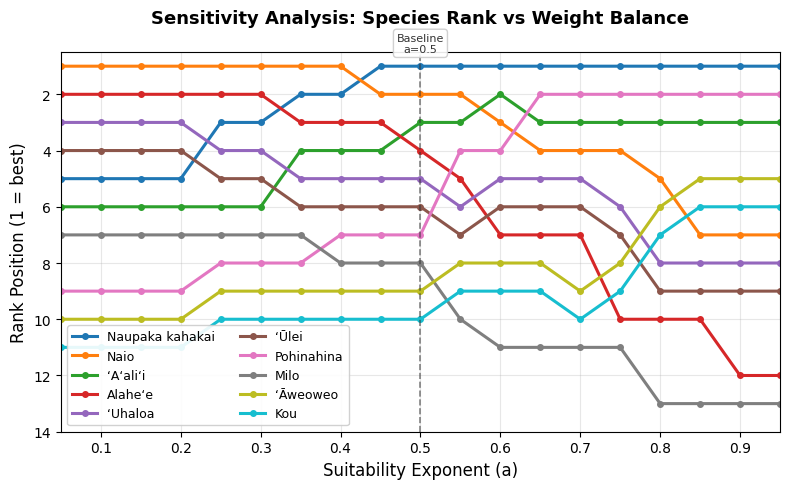

In [23]:
# Rank Position vs Suitability Exponent

fig, ax = plt.subplots(figsize=(8,5))

for ci, idx in enumerate(top10_indices):
    name = plants[idx]['hawaiian_name']
    ax.plot(a_values, all_ranks[idx], color=colors[ci], linewidth=2.2,
            marker='o', markersize=4, label=name)

ax.axvline(x=EXPONENT_S, color='#333', linestyle='--', linewidth=1.2, alpha=0.6)
ax.annotate(f'Baseline\na={EXPONENT_S}', xy=(EXPONENT_S, 0.5),
            fontsize=8, ha='center', color='#333',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))

ax.set_xlabel('Suitability Exponent (a)', fontsize=12)
ax.set_ylabel('Rank Position (1 = best)', fontsize=12)
ax.set_title('Sensitivity Analysis: Species Rank vs Weight Balance\n',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.set_ylim(max(r for ranks in all_ranks.values() for r in ranks) + 1, 0.5)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9, ncol=2)
ax.set_xlim(a_values[0], a_values[-1])
ax.grid(True, alpha=0.3)

fig.savefig('sensitivity_ranks.jpg', dpi=200, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()